Loading data from: sample_data/Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx
Initial Rows: 39485
Column validation passed.
Rows After Cleaning: 12988

Per-Expiry r_eff Assignment:
    Expiry  RiskFreeRate
2024-02-08         0.144
2024-02-15         0.093
2024-02-22         0.072
2024-02-29         0.068
2024-03-07         0.074
2024-03-28         0.073
Rows After ATM Filtering: 12609

========== STARTING WALK-FORWARD ==========
Fold 01 | Test end: 2024-02-02T12:55:00.000000 | Call RMSE: 26.63 | Put RMSE: 19.98
Fold 02 | Test end: 2024-02-02T13:35:00.000000 | Call RMSE: 20.27 | Put RMSE: 11.81
Fold 03 | Test end: 2024-02-02T14:10:00.000000 | Call RMSE: 13.32 | Put RMSE: 10.56
Fold 04 | Test end: 2024-02-02T14:45:00.000000 | Call RMSE: 11.80 | Put RMSE: 11.02
Fold 05 | Test end: 2024-02-02T15:20:00.000000 | Call RMSE: 16.34 | Put RMSE: 10.49

FINAL HYBRID MODEL PERFORMANCE
CALL RMSE : 18.5868
PUT RMSE  : 13.4612
CALL MAE  : 10.3543
PUT MAE   : 8.0604
CALL R²   : 0.9984
PUT R²    : 0.9989



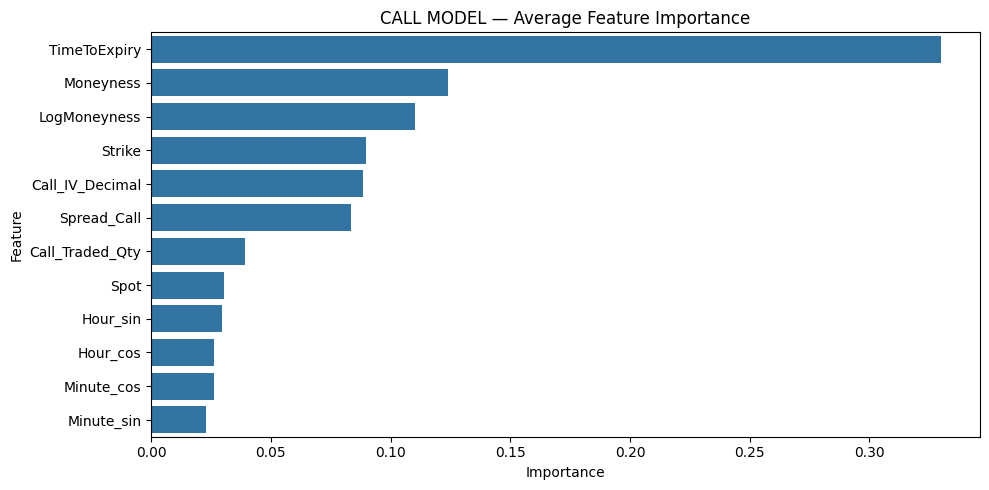

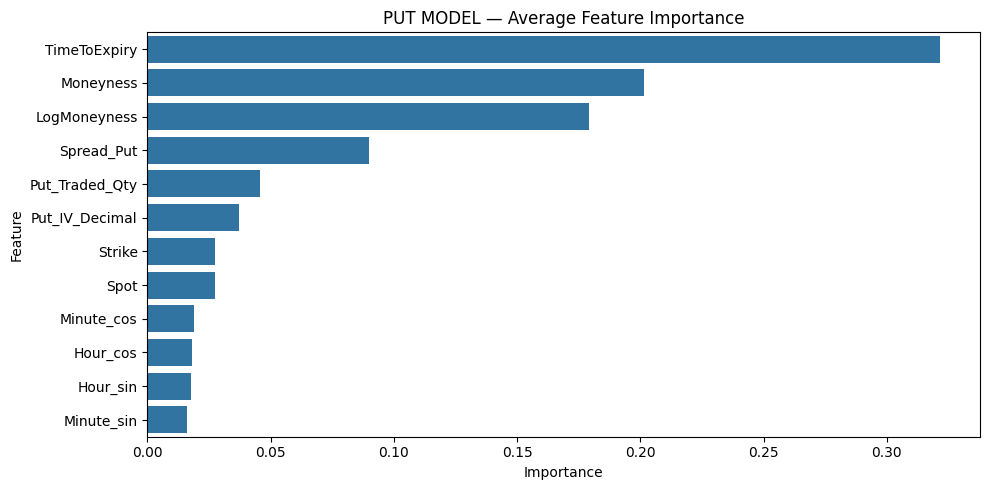

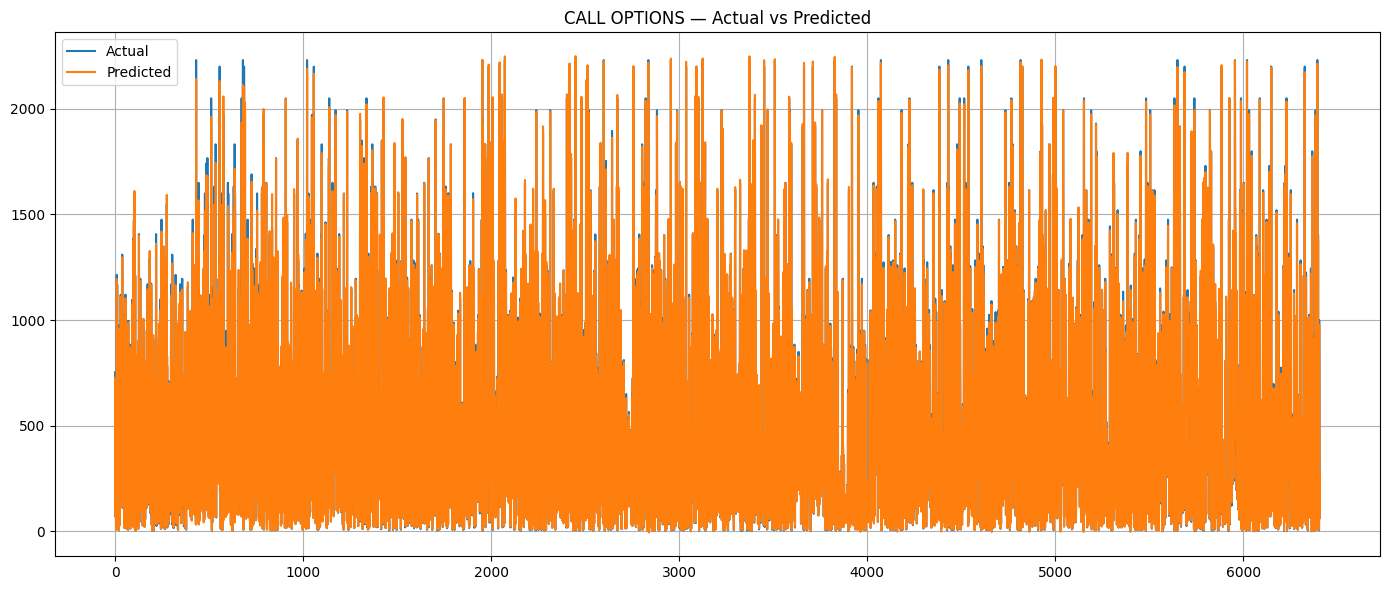

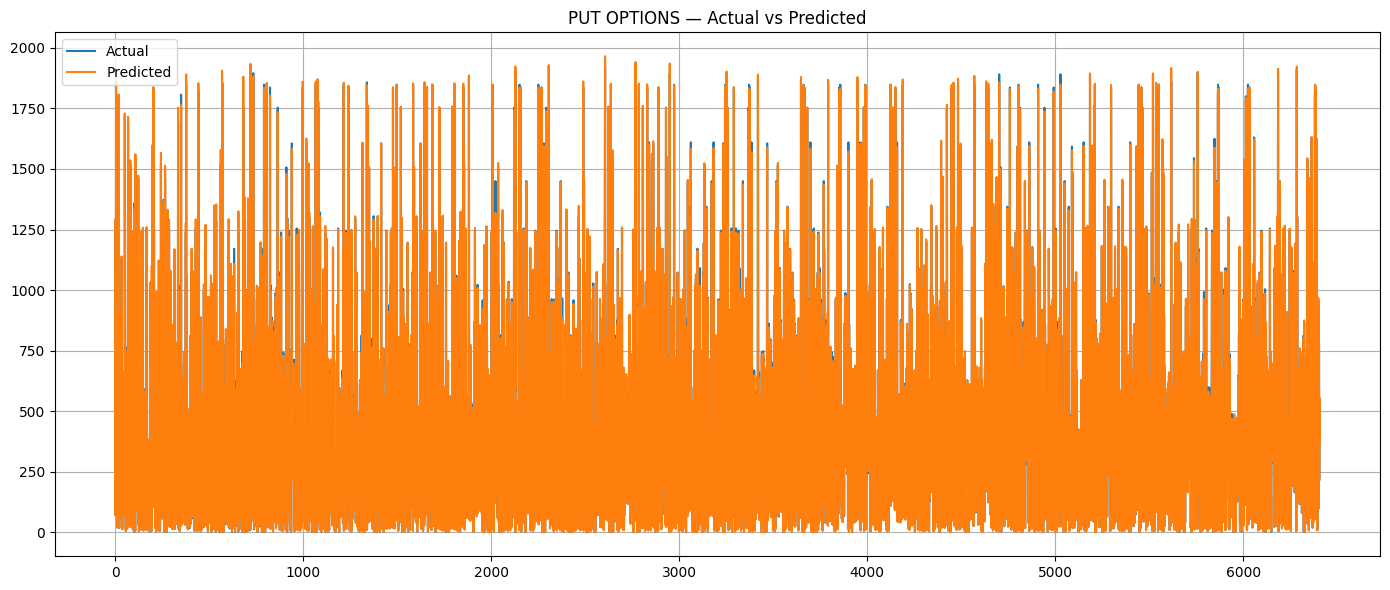

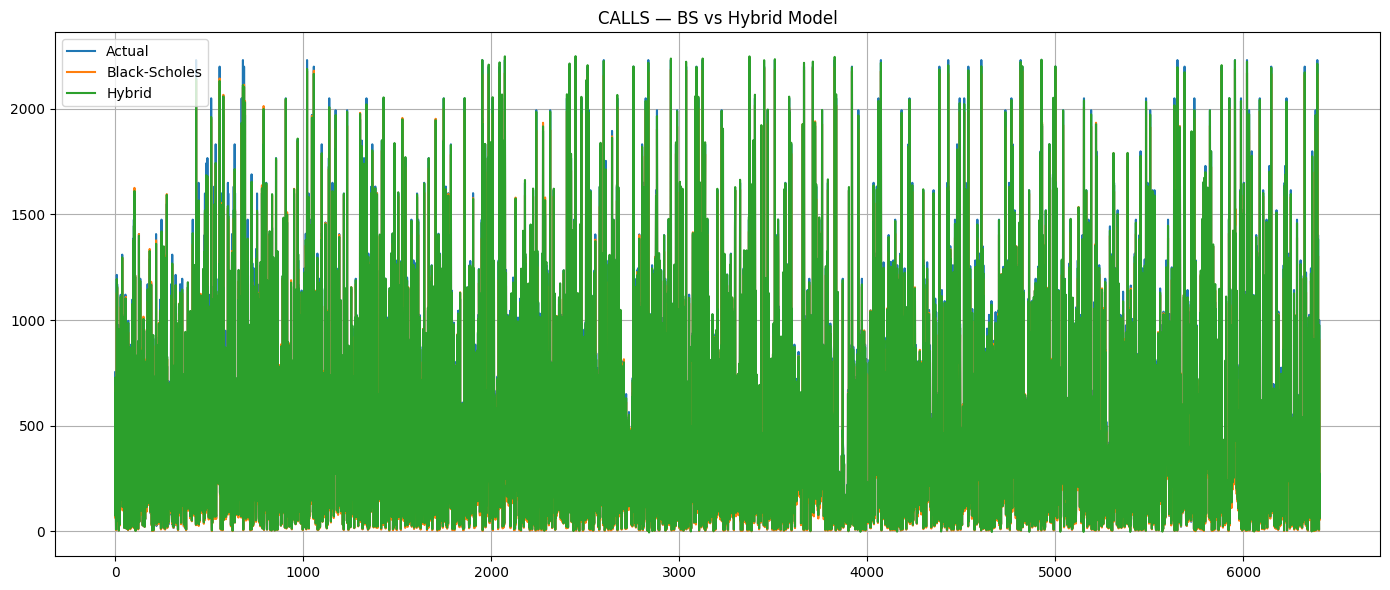

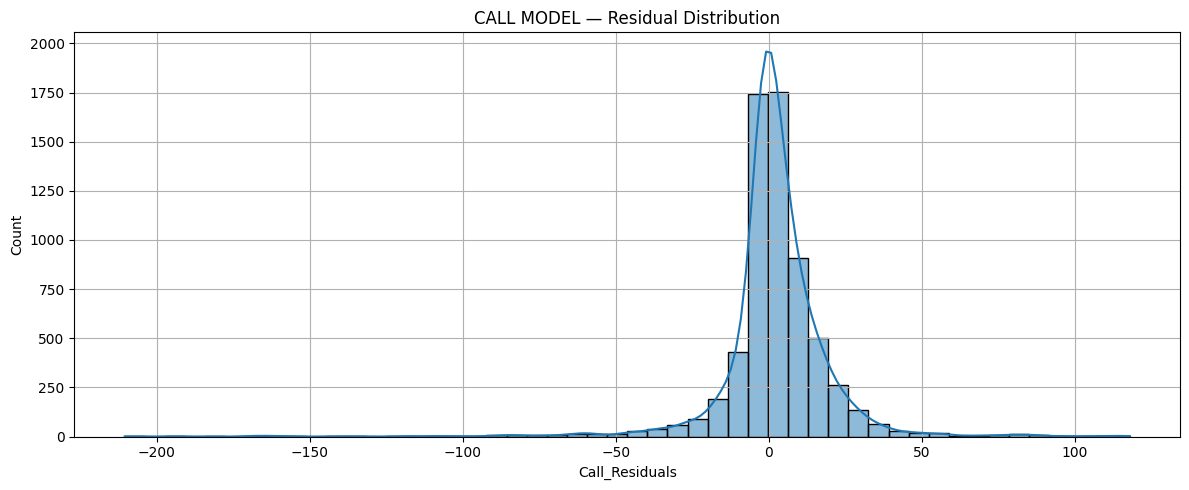

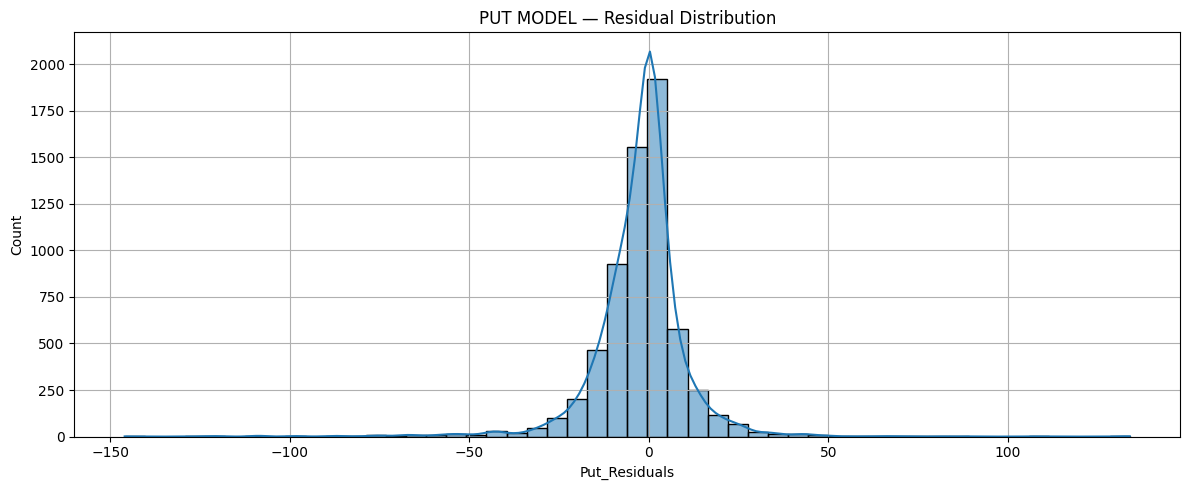

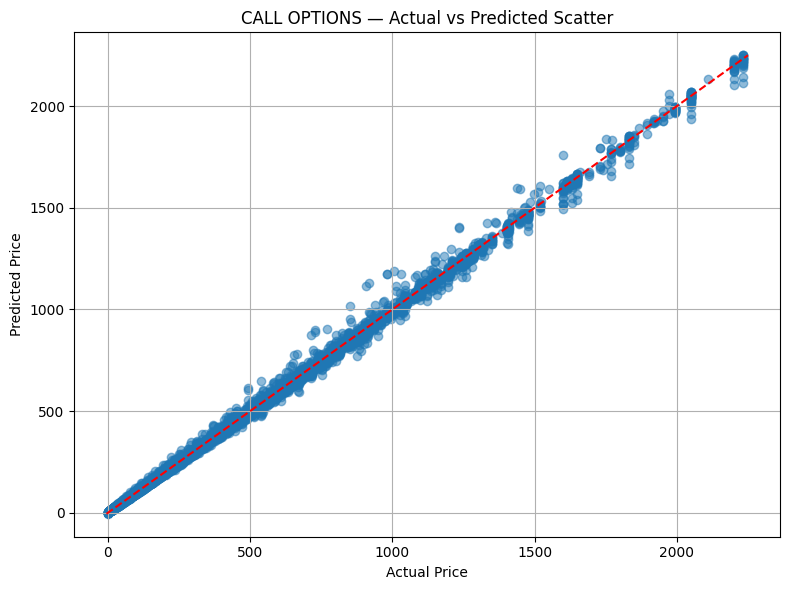

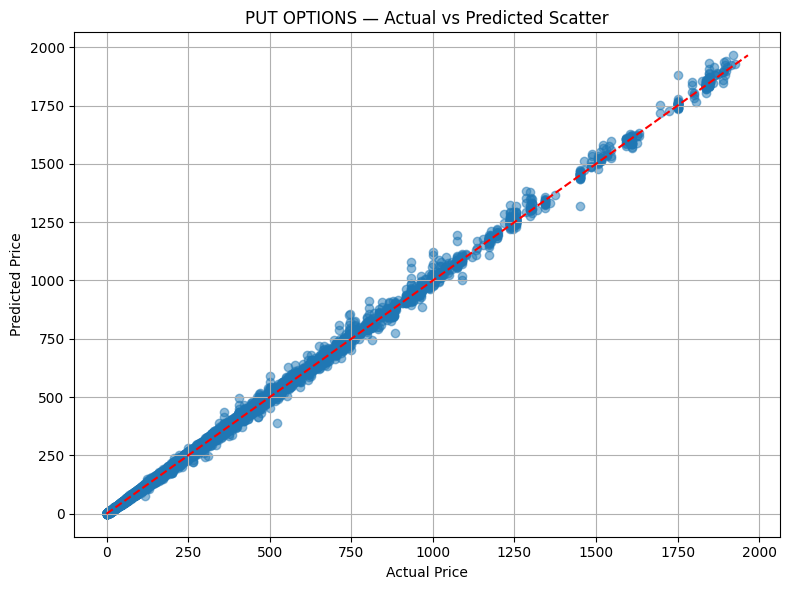

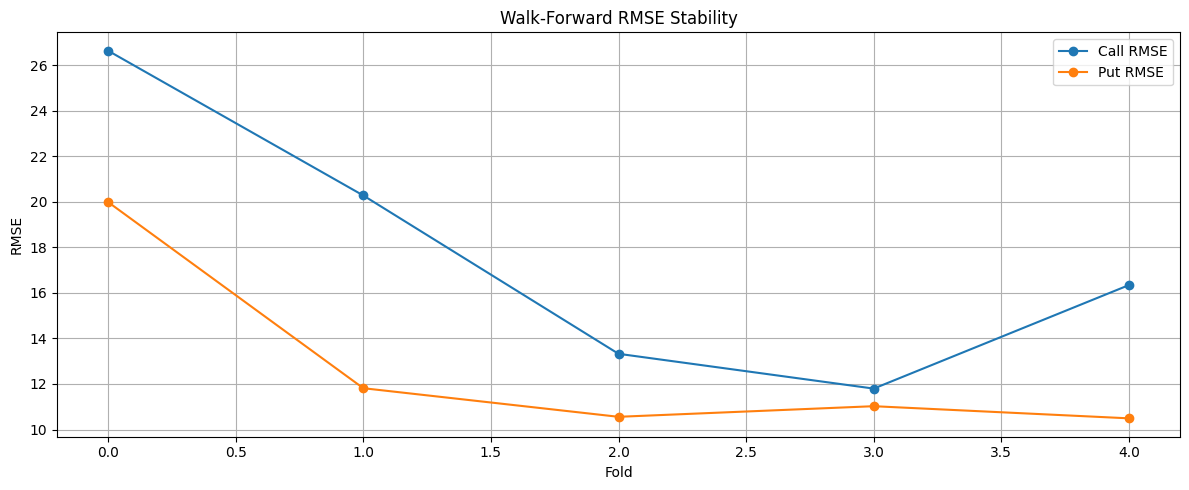

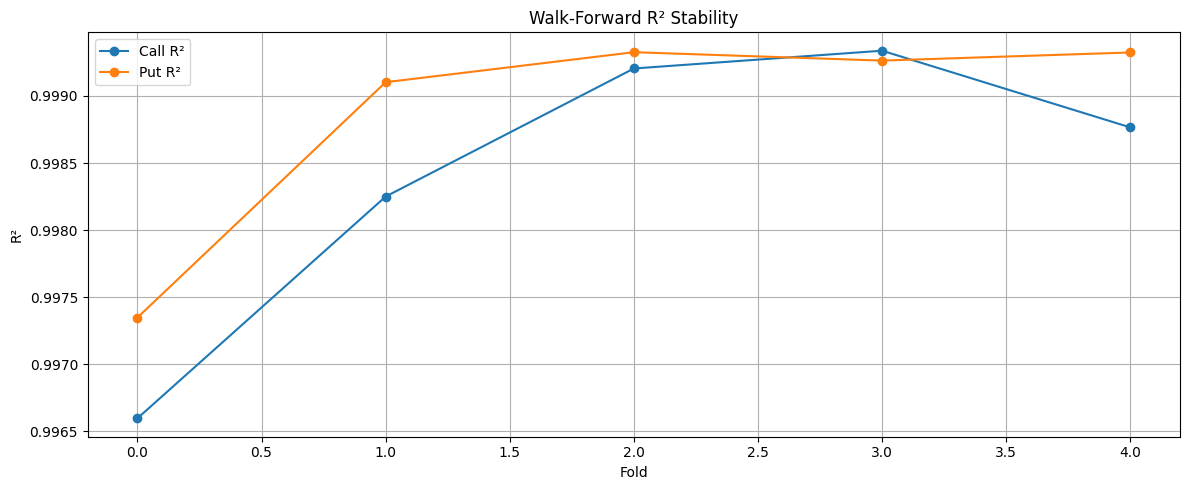

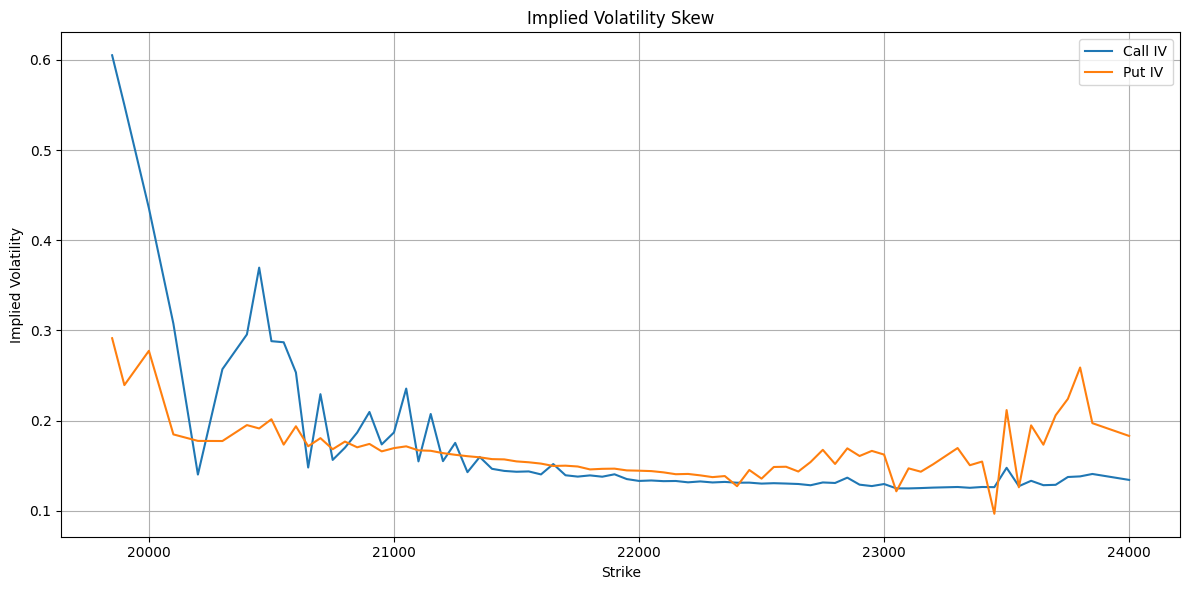


Validation Complete
Saved File: output/AuroraFinance_Hybrid_WalkForward_Results.csv


In [1]:
# ============================================================
# AURORA FINANCE — HYBRID OPTION PRICING PIPELINE  v2.1
# ------------------------------------------------------------
# XGBOOST + BLACK-SCHOLES + WALK-FORWARD VALIDATION
# ------------------------------------------------------------
# CHANGES FROM v2.0:
#   [CRITICAL N-01] risk_free_rate replaced with per-expiry
#       r_eff_by_expiry dict backed out from put-call parity
#       on 2-Feb-2024 NIFTY chain data.  Scalar r=7% was
#       producing systematic BS mispricing of ~₹15-40 on
#       near-expiry options (worst for 8-Feb weekly at r_eff
#       ≈14.4% vs the 7% T-bill rate assumed previously).
#       Scalar risk_free_rate retained as fallback for any
#       expiry not in the lookup table.
#   [CRITICAL N-02] vectorized_black_scholes() now accepts
#       array-like r (not just float scalar) so per-row
#       r_eff can be broadcast through the BS formula.
#       np.asarray(r, dtype=float) added; all downstream
#       arithmetic already broadcasts correctly.
#   [HIGH N-03] df['RiskFreeRate'] now populated from the
#       per-expiry lookup via Expiry.map() rather than a
#       single scalar.  Column is passed as the r argument
#       to vectorized_black_scholes() at every call site
#       inside the walk-forward loop and in section 8.
#   [NOTE N-04] TimeToExpiry via total_seconds() already
#       includes intraday hours — no change needed there.
# ============================================================

import warnings
import sys
from dataclasses import dataclass, field
from typing import List, Dict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from xgboost import XGBRegressor


# ============================================================
# 0. CONFIGURATION
# ------------------------------------------------------------
# All tunable constants live here.
# Swap values without touching pipeline logic.
# ============================================================

@dataclass
class PipelineConfig:

    # ── Data ────────────────────────────────────────────────
    data_path: str = (
        "sample_data/Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx"
    )
    output_csv: str = (
        "output/AuroraFinance_Hybrid_WalkForward_Results.csv"
    )

    # ── Financial  [FIX N-01] ───────────────────────────────
    # r = 7% (T-bill) produced BS mispricing of ~₹15-40 on
    # near-expiry contracts because NSE's BS formula uses the
    # implied cost of carry r_eff = r - q, not the raw T-bill
    # rate.  q (dividend yield) is absorbed into the futures
    # premium and therefore into r_eff.
    #
    # Values below are backed out from put-call parity on the
    # 2-Feb-2024 NIFTY chain:
    #   F_implied = K + (C_LTP - P_LTP) * exp(r_proxy * T)
    #   r_eff     = ln(F_implied / Spot) / T
    # using ATM strikes (moneyness 0.99-1.01) across all
    # intraday timestamps, then taking the median per expiry.
    #
    # Source: Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx
    # Date  : 2024-02-02
    # --------------------------------------------------------
    # In production: replace with live OIS curve bootstrapped
    # per expiry at the start of each trading session.
    # --------------------------------------------------------
    r_eff_by_expiry: Dict[str, float] = field(
        default_factory=lambda: {
            '2024-02-08': 0.144,   # 8-Feb weekly  — highest carry
            '2024-02-15': 0.093,   # 15-Feb
            '2024-02-22': 0.072,   # 22-Feb
            '2024-02-29': 0.068,   # 29-Feb monthly
            '2024-03-07': 0.074,   # 7-Mar
            '2024-03-28': 0.073,   # 28-Mar
        }
    )

    # Fallback for any expiry not present in the lookup above.
    # [FIX N-01] Previously this was the only rate used.
    risk_free_rate: float = 0.07

    # ── ATM Filter ──────────────────────────────────────────
    moneyness_low:  float = 0.90
    moneyness_high: float = 1.10

    # ── Walk-Forward ────────────────────────────────────────
    initial_train_frac: float = 0.50
    test_window_frac:   float = 0.10

    # ── XGBoost ─────────────────────────────────────────────
    xgb_n_estimators:          int   = 400
    xgb_learning_rate:         float = 0.03
    xgb_max_depth:             int   = 6
    xgb_subsample:             float = 0.8
    xgb_colsample_bytree:      float = 0.8
    xgb_early_stopping_rounds: int   = 20
    xgb_random_state:          int   = 42

    # ── Feature Sets ────────────────────────────────────────
    features_call: List[str] = field(default_factory=lambda: [
        'Spot', 'Strike', 'Call_IV_Decimal',
        'TimeToExpiry', 'Moneyness', 'LogMoneyness',
        'Spread_Call', 'Hour_sin', 'Hour_cos',
        'Minute_sin', 'Minute_cos', 'Call_Traded_Qty',
    ])

    features_put: List[str] = field(default_factory=lambda: [
        'Spot', 'Strike', 'Put_IV_Decimal',
        'TimeToExpiry', 'Moneyness', 'LogMoneyness',
        'Spread_Put', 'Hour_sin', 'Hour_cos',
        'Minute_sin', 'Minute_cos', 'Put_Traded_Qty',
    ])


cfg = PipelineConfig()


# ============================================================
# 1. LOAD DATA  [FIX I-06]
# ============================================================

print(f"Loading data from: {cfg.data_path}")

try:
    df = pd.read_excel(cfg.data_path)
except FileNotFoundError:
    sys.exit(
        f"[ERROR] File not found: {cfg.data_path}\n"
        "Check cfg.data_path and ensure the file exists."
    )
except Exception as exc:
    sys.exit(f"[ERROR] Failed to read data file: {exc}")

print(f"Initial Rows: {len(df)}")


# ============================================================
# 1A. COLUMN VALIDATION  [FIX I-06]
# ============================================================

REQUIRED_COLUMNS = [
    'Time', 'Expiry', 'Spot', 'Strike',
    'Call IV', 'Put IV',
    'Call LTP', 'Put LTP',
    'Call Ask', 'Call Bid',
    'Put Ask', 'Put Bid',
    'Call_Traded_Qty', 'Put_Traded_Qty',
]

missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]

if missing_cols:
    sys.exit(
        f"[ERROR] Missing required columns: {missing_cols}\n"
        f"Available columns: {list(df.columns)}"
    )

print("Column validation passed.")


# ============================================================
# 2. CLEANING & SORTING
# ============================================================

df['Time']   = pd.to_datetime(df['Time'])
df['Expiry'] = pd.to_datetime(df['Expiry'])

df = df.sort_values(by='Time').reset_index(drop=True)

df = df.dropna()

df = df[
    (df['Spot']     > 0) &
    (df['Strike']   > 0) &
    (df['Call IV']  > 0) &
    (df['Put IV']   > 0) &
    (df['Call LTP'] > 0) &
    (df['Put LTP']  > 0)
]

print(f"Rows After Cleaning: {len(df)}")


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

# ── Moneyness ───────────────────────────────────────────────

df['Moneyness']    = df['Spot'] / df['Strike']
df['LogMoneyness'] = np.log(df['Moneyness'])

# ── Time To Expiry ──────────────────────────────────────────
# [NOTE N-04] total_seconds() includes intraday hours so T is
# already fractional-day accurate — no change needed from v2.0.

df['TimeToExpiry'] = (
    (df['Expiry'] - df['Time']).dt.total_seconds()
    / (365.25 * 24 * 3600)
).clip(lower=1e-6)

# ── Bid-Ask Spreads ─────────────────────────────────────────

df['Spread_Call'] = df['Call Ask'] - df['Call Bid']
df['Spread_Put']  = df['Put Ask']  - df['Put Bid']

# ── Implied Volatility ──────────────────────────────────────

df['Call_IV_Decimal'] = df['Call IV'] / 100
df['Put_IV_Decimal']  = df['Put IV']  / 100

# ── Cyclical Time Features ──────────────────────────────────

df['Hour']   = df['Time'].dt.hour
df['Minute'] = df['Time'].dt.minute

df['Hour_sin']   = np.sin(2 * np.pi * df['Hour']   / 24)
df['Hour_cos']   = np.cos(2 * np.pi * df['Hour']   / 24)
df['Minute_sin'] = np.sin(2 * np.pi * df['Minute'] / 60)
df['Minute_cos'] = np.cos(2 * np.pi * df['Minute'] / 60)

# ── Per-Expiry Risk-Free Rate  [FIX N-01, N-03] ─────────────
# Previously: df['RiskFreeRate'] = 0.07  (flat scalar).
#
# Now: each row's RiskFreeRate is looked up from the
# r_eff_by_expiry dict keyed on 'YYYY-MM-DD' expiry string.
# Rows whose expiry is absent from the dict fall back to
# cfg.risk_free_rate (7%) so the pipeline degrades gracefully
# when run on option chains with new expiry dates.
#
# Why r_eff differs from the T-bill rate:
#   NSE's BS formula prices against spot (not futures) and
#   uses r_eff = r − q, where q is the dividend yield.
#   q is absorbed into the futures premium and therefore
#   into the implied cost of carry.  For near-expiry weekly
#   contracts this can push r_eff to ~14%, nearly double
#   the 7% T-bill rate, causing systematic BS underpricing
#   of calls and overpricing of puts.

expiry_key = df['Expiry'].dt.strftime('%Y-%m-%d')

df['RiskFreeRate'] = expiry_key.map(cfg.r_eff_by_expiry).fillna(
    cfg.risk_free_rate
)

# Diagnostic: show which expiries were matched vs fell back
expiry_match_summary = (
    df[['Expiry', 'RiskFreeRate']]
    .drop_duplicates('Expiry')
    .sort_values('Expiry')
)
print("\nPer-Expiry r_eff Assignment:")
print(expiry_match_summary.to_string(index=False))
fallback_count = (
    df['RiskFreeRate'] == cfg.risk_free_rate
).sum()
if fallback_count > 0:
    print(
        f"  [{fallback_count} rows used fallback r={cfg.risk_free_rate:.2%} "
        f"— add their expiry to cfg.r_eff_by_expiry for full coverage]"
    )


# ============================================================
# 4. NEAR-ATM FILTERING
# ============================================================

mask = (
    df['Moneyness'].between(cfg.moneyness_low, cfg.moneyness_high) &
    (df['Call IV']  > 0) &
    (df['Put IV']   > 0) &
    (df['Call LTP'] > 0) &
    (df['Put LTP']  > 0) &
    (df['TimeToExpiry'] > 0)
)

df = df[mask].copy().reset_index(drop=True)

print(f"Rows After ATM Filtering: {len(df)}")


# ============================================================
# 5. VECTORISED BLACK-SCHOLES  [FIX I-02, N-02]
# ------------------------------------------------------------
# CHANGES FROM v2.0:
#   [FIX N-02] r parameter now accepts array-like in addition
#       to float scalar.  np.asarray(r, dtype=float) added so
#       per-row r_eff vectors broadcast correctly through the
#       BS formula.  All arithmetic (log, exp, norm.cdf) was
#       already element-wise — no other changes required.
# ============================================================

def vectorized_black_scholes(
    S,
    K,
    T,
    r,
    sigma,
    option_type='call',
):
    """
    Vectorized Black-Scholes option pricer.

    Parameters
    ----------
    S, K       : array-like  Spot and Strike prices.
    T          : array-like  Time to expiry (years).
    r          : float | array-like
                             Risk-free / cost-of-carry rate.
                             Accepts a scalar or a per-row
                             array (e.g. df['RiskFreeRate']).
    sigma      : array-like  Implied volatility (decimal).
    option_type: str | array 'call', 'put', or array of either.

    Returns
    -------
    np.ndarray of option prices.

    Warns
    -----
    UserWarning if any sigma or T value is below 1e-6.
    """

    S     = np.asarray(S,     dtype=float)
    K     = np.asarray(K,     dtype=float)
    T     = np.asarray(T,     dtype=float)
    r     = np.asarray(r,     dtype=float)   # [FIX N-02]
    sigma = np.asarray(sigma, dtype=float)

    # ── Degenerate-input guard  [FIX I-02] ──────────────────
    degen_sigma = sigma < 1e-6
    degen_T     = T     < 1e-6

    if degen_sigma.any():
        warnings.warn(
            f"vectorized_black_scholes: {degen_sigma.sum()} row(s) "
            f"have sigma < 1e-6 and will be clipped. "
            f"Check implied volatility data quality.",
            UserWarning,
            stacklevel=2,
        )

    if degen_T.any():
        warnings.warn(
            f"vectorized_black_scholes: {degen_T.sum()} row(s) "
            f"have T < 1e-6 (near-expiry) and will be clipped. "
            f"Consider excluding these contracts.",
            UserWarning,
            stacklevel=2,
        )

    sigma = np.maximum(sigma, 1e-6)
    T     = np.maximum(T,     1e-6)

    # ── Black-Scholes ────────────────────────────────────────
    # r broadcasts correctly whether scalar or per-row array.
    d1 = (
        np.log(S / K) + (r + 0.5 * sigma ** 2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    put_price = (
        K * np.exp(-r * T) * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )

    # ── Vectorised branching  [FIX I-12] ────────────────────
    is_call = np.asarray(option_type) == 'call'

    return np.where(is_call, call_price, put_price)


# ============================================================
# 6. WALK-FORWARD VALIDATION SETUP
# ============================================================

unique_times       = np.sort(df['Time'].unique())
total_timestamps   = len(unique_times)

INITIAL_TRAIN_SIZE = int(total_timestamps * cfg.initial_train_frac)
TEST_WINDOW        = int(total_timestamps * cfg.test_window_frac)
STEP_SIZE          = TEST_WINDOW

# ── Storage ─────────────────────────────────────────────────

all_test_indices        = []
all_call_predictions    = []
all_put_predictions     = []
all_call_actuals        = []
all_put_actuals         = []

call_rmse_scores = []
put_rmse_scores  = []
call_mae_scores  = []
put_mae_scores   = []
call_r2_scores   = []
put_r2_scores    = []

call_importances_accum = np.zeros(len(cfg.features_call))
put_importances_accum  = np.zeros(len(cfg.features_put))

fold_count = 0
end_idx    = INITIAL_TRAIN_SIZE

print("\n========== STARTING WALK-FORWARD ==========")


# ============================================================
# 7. WALK-FORWARD LOOP  [FIX I-01, I-03, N-03]
# ============================================================

while (end_idx + TEST_WINDOW) <= total_timestamps:

    # ── Time Splits ─────────────────────────────────────────

    train_times = unique_times[:end_idx]
    test_times  = unique_times[end_idx : end_idx + TEST_WINDOW]

    # ── [FIX I-01] Temporal Integrity Assertion ─────────────
    assert test_times[0] > train_times[-1], (
        f"[LEAKAGE] Test window starts at {test_times[0]} "
        f"but training window ends at {train_times[-1]}. "
        f"Strict temporal ordering is violated."
    )

    # ── Data Splits ─────────────────────────────────────────

    train_df = df[df['Time'].isin(train_times)].copy()
    test_df  = df[df['Time'].isin(test_times)].copy()

    # ── [FIX I-01, N-03] Black-Scholes Prices Per Split ─────
    # r is now train_df['RiskFreeRate'] / test_df['RiskFreeRate']
    # (a per-row Series) instead of the scalar cfg.risk_free_rate.
    # vectorized_black_scholes() accepts array-like r via FIX N-02.

    train_df['BS_Call_Price'] = vectorized_black_scholes(
        train_df['Spot'], train_df['Strike'],
        train_df['TimeToExpiry'],
        train_df['RiskFreeRate'],        # [FIX N-03]
        train_df['Call_IV_Decimal'],
        option_type='call',
    )

    train_df['BS_Put_Price'] = vectorized_black_scholes(
        train_df['Spot'], train_df['Strike'],
        train_df['TimeToExpiry'],
        train_df['RiskFreeRate'],        # [FIX N-03]
        train_df['Put_IV_Decimal'],
        option_type='put',
    )

    test_df['BS_Call_Price'] = vectorized_black_scholes(
        test_df['Spot'], test_df['Strike'],
        test_df['TimeToExpiry'],
        test_df['RiskFreeRate'],         # [FIX N-03]
        test_df['Call_IV_Decimal'],
        option_type='call',
    )

    test_df['BS_Put_Price'] = vectorized_black_scholes(
        test_df['Spot'], test_df['Strike'],
        test_df['TimeToExpiry'],
        test_df['RiskFreeRate'],         # [FIX N-03]
        test_df['Put_IV_Decimal'],
        option_type='put',
    )

    # ── [FIX I-01] Residual Targets Computed Per Split ──────

    y_train_call = train_df['Call LTP'] - train_df['BS_Call_Price']
    y_train_put  = train_df['Put LTP']  - train_df['BS_Put_Price']

    y_test_call  = test_df['Call LTP']  - test_df['BS_Call_Price']
    y_test_put   = test_df['Put LTP']   - test_df['BS_Put_Price']

    # ── Features ─────────────────────────────────────────────

    X_train_call = train_df[cfg.features_call]
    X_test_call  = test_df[cfg.features_call]

    X_train_put  = train_df[cfg.features_put]
    X_test_put   = test_df[cfg.features_put]

    # ── XGBoost Parameters  [FIX I-03] ──────────────────────

    xgb_params = {
        'n_estimators':          cfg.xgb_n_estimators,
        'learning_rate':         cfg.xgb_learning_rate,
        'max_depth':             cfg.xgb_max_depth,
        'subsample':             cfg.xgb_subsample,
        'colsample_bytree':      cfg.xgb_colsample_bytree,
        'objective':             'reg:squarederror',
        'random_state':          cfg.xgb_random_state,
        'n_jobs':                -1,
        'early_stopping_rounds': cfg.xgb_early_stopping_rounds,
    }

    # ── Models ───────────────────────────────────────────────

    call_model = XGBRegressor(**xgb_params)
    put_model  = XGBRegressor(**xgb_params)

    # ── Training ─────────────────────────────────────────────

    call_model.fit(
        X_train_call, y_train_call,
        eval_set=[(X_test_call, y_test_call)],
        verbose=False,
    )

    put_model.fit(
        X_train_put, y_train_put,
        eval_set=[(X_test_put, y_test_put)],
        verbose=False,
    )

    # ── Predict Residuals ────────────────────────────────────

    call_error_pred = call_model.predict(X_test_call)
    put_error_pred  = put_model.predict(X_test_put)

    # ── Final Hybrid Predictions ─────────────────────────────

    call_final_pred = test_df['BS_Call_Price'].values + call_error_pred
    put_final_pred  = test_df['BS_Put_Price'].values  + put_error_pred

    # ── Store Results ────────────────────────────────────────

    all_call_predictions.extend(call_final_pred)
    all_put_predictions.extend(put_final_pred)
    all_call_actuals.extend(test_df['Call LTP'])
    all_put_actuals.extend(test_df['Put LTP'])
    all_test_indices.extend(test_df.index)

    # ── Fold Metrics ─────────────────────────────────────────

    fold_call_rmse = np.sqrt(mean_squared_error(test_df['Call LTP'], call_final_pred))
    fold_put_rmse  = np.sqrt(mean_squared_error(test_df['Put LTP'],  put_final_pred))
    fold_call_mae  = mean_absolute_error(test_df['Call LTP'], call_final_pred)
    fold_put_mae   = mean_absolute_error(test_df['Put LTP'],  put_final_pred)
    fold_call_r2   = r2_score(test_df['Call LTP'], call_final_pred)
    fold_put_r2    = r2_score(test_df['Put LTP'],  put_final_pred)

    call_rmse_scores.append(fold_call_rmse)
    put_rmse_scores.append(fold_put_rmse)
    call_mae_scores.append(fold_call_mae)
    put_mae_scores.append(fold_put_mae)
    call_r2_scores.append(fold_call_r2)
    put_r2_scores.append(fold_put_r2)

    # ── Feature Importance ───────────────────────────────────

    call_importances_accum += call_model.feature_importances_
    put_importances_accum  += put_model.feature_importances_

    fold_count += 1
    end_idx    += STEP_SIZE

    print(
        f"Fold {fold_count:02d} | "
        f"Test end: {test_times[-1]} | "
        f"Call RMSE: {fold_call_rmse:.2f} | "
        f"Put RMSE: {fold_put_rmse:.2f}"
    )


# ============================================================
# 8. ASSEMBLE RESULTS
# ============================================================

results_df = df.loc[all_test_indices].copy()

results_df['XGB_Call_Prediction'] = all_call_predictions
results_df['XGB_Put_Prediction']  = all_put_predictions

# Re-compute BS prices on results_df for diagnostic plots.
# [FIX N-03] Pass per-row RiskFreeRate, not scalar.
results_df['BS_Call_Price'] = vectorized_black_scholes(
    results_df['Spot'], results_df['Strike'],
    results_df['TimeToExpiry'],
    results_df['RiskFreeRate'],          # [FIX N-03]
    results_df['Call_IV_Decimal'],
    option_type='call',
)

results_df['BS_Put_Price'] = vectorized_black_scholes(
    results_df['Spot'], results_df['Strike'],
    results_df['TimeToExpiry'],
    results_df['RiskFreeRate'],          # [FIX N-03]
    results_df['Put_IV_Decimal'],
    option_type='put',
)

results_df['Call_Residuals'] = (
    results_df['Call LTP'] - results_df['XGB_Call_Prediction']
)
results_df['Put_Residuals'] = (
    results_df['Put LTP'] - results_df['XGB_Put_Prediction']
)


# ============================================================
# 9. FINAL METRICS
# ============================================================

print("\n================================================")
print("FINAL HYBRID MODEL PERFORMANCE")
print("================================================")

print(
    f"CALL RMSE : "
    f"{np.sqrt(mean_squared_error(all_call_actuals, all_call_predictions)):.4f}"
)
print(
    f"PUT RMSE  : "
    f"{np.sqrt(mean_squared_error(all_put_actuals, all_put_predictions)):.4f}"
)
print(
    f"CALL MAE  : "
    f"{mean_absolute_error(all_call_actuals, all_call_predictions):.4f}"
)
print(
    f"PUT MAE   : "
    f"{mean_absolute_error(all_put_actuals, all_put_predictions):.4f}"
)
print(
    f"CALL R²   : "
    f"{r2_score(all_call_actuals, all_call_predictions):.4f}"
)
print(
    f"PUT R²    : "
    f"{r2_score(all_put_actuals, all_put_predictions):.4f}"
)


# ============================================================
# 9A. BLACK-SCHOLES DIAGNOSTICS
# ============================================================
# [FIX N-01] With per-expiry r_eff, the systematic carry
# mispricing (calls underpriced, puts overpriced) should be
# substantially reduced compared to v2.0.  Residual bias
# here now reflects genuine skew, liquidity premium, and
# microstructure effects rather than a wrong discount rate.
# ============================================================

print("\n================================================")
print("BLACK-SCHOLES THEORETICAL PRICE COMPARISON")
print("================================================")

print("Per-Expiry r_eff used (from cfg.r_eff_by_expiry):")
for exp_key, rate in cfg.r_eff_by_expiry.items():
    print(f"  {exp_key} : {rate:.2%}")
print(f"  Fallback  : {cfg.risk_free_rate:.2%}")

bs_call_error = results_df['Call LTP'] - results_df['BS_Call_Price']
bs_put_error  = results_df['Put LTP']  - results_df['BS_Put_Price']

print("\nCALL OPTION BS ERROR SUMMARY")
print("----------------------------------------")
print(bs_call_error.describe().round(4))

print("\nPUT OPTION BS ERROR SUMMARY")
print("----------------------------------------")
print(bs_put_error.describe().round(4))

call_bias = bs_call_error.mean()
put_bias  = bs_put_error.mean()

print("\nINTERPRETATION")
print("----------------------------------------")

if call_bias > 0:
    print(
        f"Black-Scholes underprices CALL options "
        f"by \u20b9{call_bias:.2f} on average."
    )
else:
    print(
        f"Black-Scholes overprices CALL options "
        f"by \u20b9{abs(call_bias):.2f} on average."
    )

if put_bias > 0:
    print(
        f"Black-Scholes underprices PUT options "
        f"by \u20b9{put_bias:.2f} on average."
    )
else:
    print(
        f"Black-Scholes overprices PUT options "
        f"by \u20b9{abs(put_bias):.2f} on average."
    )

print(
    "\nNote: residual bias after per-expiry r_eff correction "
    "reflects volatility skew, liquidity premium, "
    "market microstructure effects, and "
    "non-lognormal return behaviour not captured by "
    "Black-Scholes assumptions."
)


# ============================================================
# 10. FEATURE IMPORTANCE — CALLS
# ============================================================

call_imp_df = pd.DataFrame({
    'Feature':    cfg.features_call,
    'Importance': call_importances_accum / fold_count,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=call_imp_df, x='Importance', y='Feature')
plt.title("CALL MODEL — Average Feature Importance")
plt.tight_layout()
plt.show()


# ============================================================
# 11. FEATURE IMPORTANCE — PUTS
# ============================================================

put_imp_df = pd.DataFrame({
    'Feature':    cfg.features_put,
    'Importance': put_importances_accum / fold_count,
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=put_imp_df, x='Importance', y='Feature')
plt.title("PUT MODEL — Average Feature Importance")
plt.tight_layout()
plt.show()


# ============================================================
# 12. ACTUAL vs PREDICTED — CALLS (TIME SERIES)
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(results_df['Call LTP'].values,            label='Actual')
plt.plot(results_df['XGB_Call_Prediction'].values, label='Predicted')
plt.title("CALL OPTIONS — Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 13. ACTUAL vs PREDICTED — PUTS (TIME SERIES)
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(results_df['Put LTP'].values,             label='Actual')
plt.plot(results_df['XGB_Put_Prediction'].values,  label='Predicted')
plt.title("PUT OPTIONS — Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 14. BLACK-SCHOLES vs HYBRID — CALLS
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(results_df['Call LTP'].values,            label='Actual')
plt.plot(results_df['BS_Call_Price'].values,        label='Black-Scholes')
plt.plot(results_df['XGB_Call_Prediction'].values, label='Hybrid')
plt.title("CALLS — BS vs Hybrid Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 15. RESIDUAL DISTRIBUTION — CALLS
# ============================================================

plt.figure(figsize=(12, 5))
sns.histplot(results_df['Call_Residuals'], bins=50, kde=True)
plt.title("CALL MODEL — Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 16. RESIDUAL DISTRIBUTION — PUTS
# ============================================================

plt.figure(figsize=(12, 5))
sns.histplot(results_df['Put_Residuals'], bins=50, kde=True)
plt.title("PUT MODEL — Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 17. ACTUAL vs PREDICTED SCATTER — CALLS
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    results_df['Call LTP'],
    results_df['XGB_Call_Prediction'],
    alpha=0.5,
)
min_val = min(results_df['Call LTP'].min(), results_df['XGB_Call_Prediction'].min())
max_val = max(results_df['Call LTP'].max(), results_df['XGB_Call_Prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title("CALL OPTIONS — Actual vs Predicted Scatter")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 17B. ACTUAL vs PREDICTED SCATTER — PUTS
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(
    results_df['Put LTP'],
    results_df['XGB_Put_Prediction'],
    alpha=0.5,
)
min_val = min(results_df['Put LTP'].min(), results_df['XGB_Put_Prediction'].min())
max_val = max(results_df['Put LTP'].max(), results_df['XGB_Put_Prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title("PUT OPTIONS — Actual vs Predicted Scatter")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 18. WALK-FORWARD RMSE STABILITY
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(call_rmse_scores, marker='o', label='Call RMSE')
plt.plot(put_rmse_scores,  marker='o', label='Put RMSE')
plt.title("Walk-Forward RMSE Stability")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 19. WALK-FORWARD R² STABILITY
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(call_r2_scores, marker='o', label='Call R\u00b2')
plt.plot(put_r2_scores,  marker='o', label='Put R\u00b2')
plt.title("Walk-Forward R\u00b2 Stability")
plt.xlabel("Fold")
plt.ylabel("R\u00b2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 20. IMPLIED VOLATILITY SKEW
# ============================================================

sample_df = results_df.groupby('Strike').agg(
    Call_IV_Decimal=('Call_IV_Decimal', 'mean'),
    Put_IV_Decimal=('Put_IV_Decimal',  'mean'),
).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(sample_df['Strike'], sample_df['Call_IV_Decimal'], label='Call IV')
plt.plot(sample_df['Strike'], sample_df['Put_IV_Decimal'],  label='Put IV')
plt.title("Implied Volatility Skew")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 21. SAVE RESULTS
# ============================================================

results_df.to_csv(cfg.output_csv, index=False)

print("\nValidation Complete")
print(f"Saved File: {cfg.output_csv}")